In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/cifar-10/trainLabels.csv
/kaggle/input/competitions/cifar-10/sampleSubmission.csv
/kaggle/input/competitions/cifar-10/test.7z
/kaggle/input/competitions/cifar-10/train.7z


2026-04-17 08:07:15.794826: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776413235.998931      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776413236.058866      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776413236.523942      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776413236.523989      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776413236.523993      16 computation_placer.cc:177] computation placer alr

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


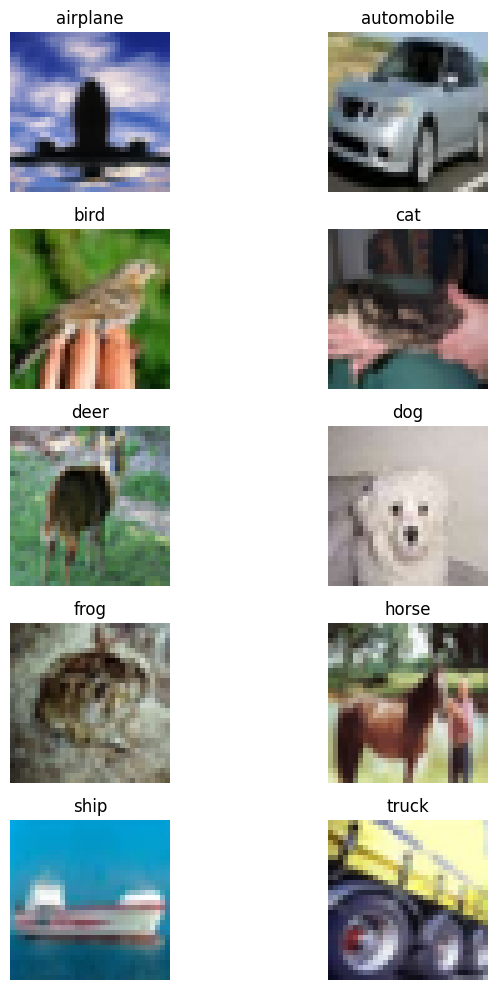

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, datasets
import warnings

warnings.filterwarnings('ignore')

# 1. CIFAR-10 데이터 로드
(X_train_full, y_train_full), (X_test, y_test) = datasets.cifar10.load_data()
X_train_full = X_train_full.astype('float32')
X_test = X_test.astype('float32')
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# 2. 정규화 (0~1 범위로)
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# 3. 훈련/검증 분할 (8:2)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

# 4. 클래스 이름
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 5. 시각화
fig, axes = plt.subplots(5, 2, figsize=(8, 10))
for class_idx in range(10):
    indices = np.where(y_train == class_idx)[0] # 빈칸 채움: np.where
    idx = indices[0] if len(indices) > 0 else 0
    row, col = class_idx // 2, class_idx % 2
    axes[row, col].imshow(X_train[idx])
    axes[row, col].set_title(class_names[class_idx])
    axes[row, col].axis('off') # 빈칸 채움: axis
plt.tight_layout()
plt.show()

In [3]:
model = keras.Sequential([
    # 합성곱층 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)), # 빈칸 채움: MaxPooling2D
    
    # 합성곱층 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)), # 빈칸 채움: MaxPooling2D
    
    # 합성곱층 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)), # 빈칸 채움: MaxPooling2D
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # 빈칸 채움: Dropout
    
    # 출력층 (10개 클래스 다중분류)
    layers.Dense(10, activation='softmax') # 빈칸 채움: softmax
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', # 빈칸 채움: 라벨이 정수이므로 sparse 사용
    metrics=['accuracy']
)

model.summary()

2026-04-17 08:07:52.716695: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 137ms/step - accuracy: 0.3067 - loss: 1.8908 - val_accuracy: 0.5244 - val_loss: 1.3179
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.5338 - loss: 1.3079 - val_accuracy: 0.6087 - val_loss: 1.1245
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.6116 - loss: 1.1068 - val_accuracy: 0.6608 - val_loss: 0.9787
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.6522 - loss: 0.9805 - val_accuracy: 0.6845 - val_loss: 0.8991
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.6954 - loss: 0.8682 - val_accuracy: 0.7094 - val_loss: 0.8468
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.7230 - loss: 0.8003 - val_accuracy: 0.7201 - val_loss: 0.8129
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.7415 - loss: 0.7397 - val_accuracy: 0.7316 - val_loss: 0.7778
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.7610 -

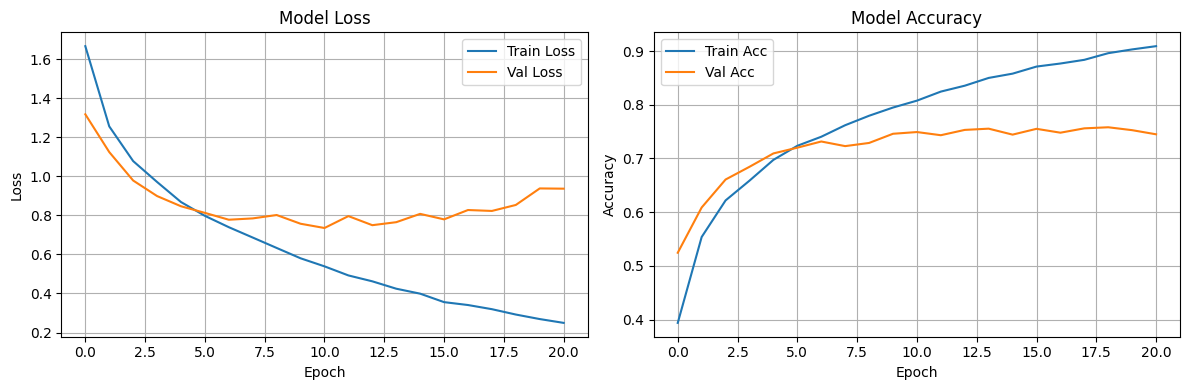

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7550 - loss: 0.7243

=== 검증 성능 ===
Loss: 0.7354
정확도: 0.7492 (74.92%)
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7515 - loss: 0.7387

=== 테스트 성능 (최종) ===
Loss: 0.7439
정확도: 0.7496 (74.96%)
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step

예측 신뢰도:
  평균: 0.7925
  최소: 0.1673
  최대: 1.0000


In [5]:
# 1. 훈련/검증 손실 & 정확도 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 손실 그래프
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss')
axes[0].legend()
axes[0].grid(True)

# 정확도 그래프
axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 2. 최종 성능 평가
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"\n=== 검증 성능 ===")
print(f"Loss: {val_loss:.4f}")
print(f"정확도: {val_acc:.4f} ({val_acc*100:.2f}%)")

# 테스트 성능 (최종 평가)
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n=== 테스트 성능 (최종) ===")
print(f"Loss: {test_loss:.4f}")
print(f"정확도: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 3. 예측 확률 분석
y_val_pred_proba = model.predict(X_val)

# ✅ 빈칸 채움: 확률을 클래스 인덱스로 변환
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# ✅ 빈칸 채움: 신뢰도(가장 높은 확률값) 확인
confidence = np.max(y_val_pred_proba, axis=1)

print(f"\n예측 신뢰도:")
print(f"  평균: {confidence.mean():.4f}")
print(f"  최소: {confidence.min():.4f}")
print(f"  최대: {confidence.max():.4f}")

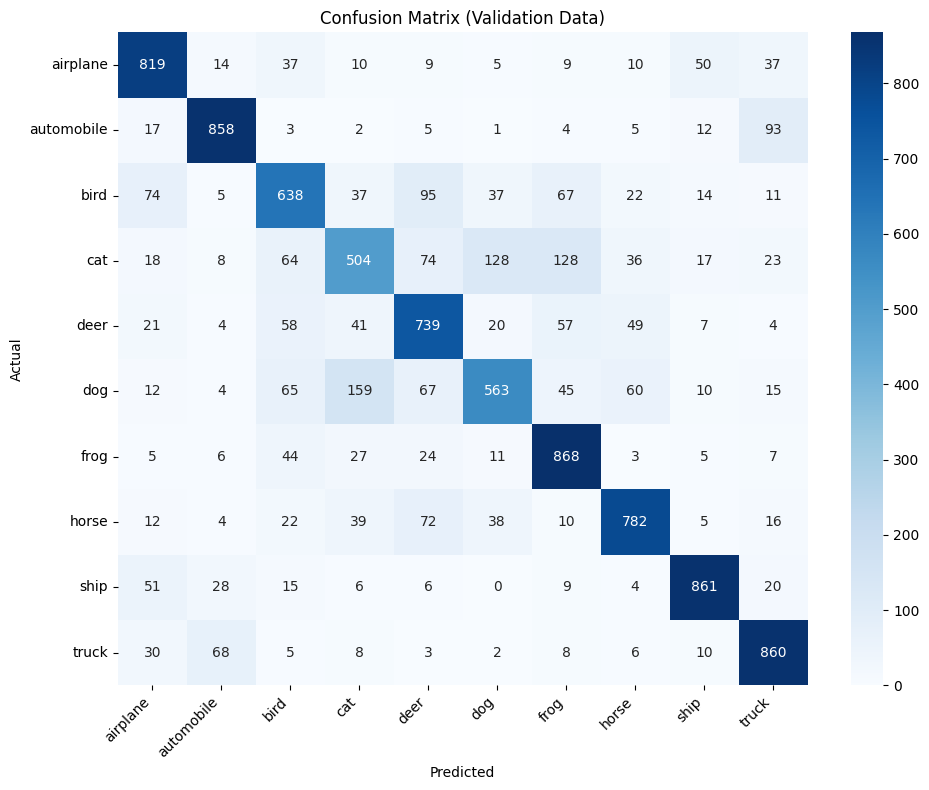


분류 리포트:
              precision    recall  f1-score   support

    airplane       0.77      0.82      0.80      1000
  automobile       0.86      0.86      0.86      1000
        bird       0.67      0.64      0.65      1000
         cat       0.61      0.50      0.55      1000
        deer       0.68      0.74      0.71      1000
         dog       0.70      0.56      0.62      1000
        frog       0.72      0.87      0.79      1000
       horse       0.80      0.78      0.79      1000
        ship       0.87      0.86      0.86      1000
       truck       0.79      0.86      0.82      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000


클래스별 정확도:
  airplane: 0.8190 (81.90%)
  automobile: 0.8580 (85.80%)
  bird: 0.6380 (63.80%)
  cat: 0.5040 (50.40%)
  deer: 0.7390 (73.90%)
  dog: 0.5630 (56.30%)
  frog: 0.8680 (86.80%)
  horse: 0.7820 (78.20%)
  ship: 0.8610 (86.1

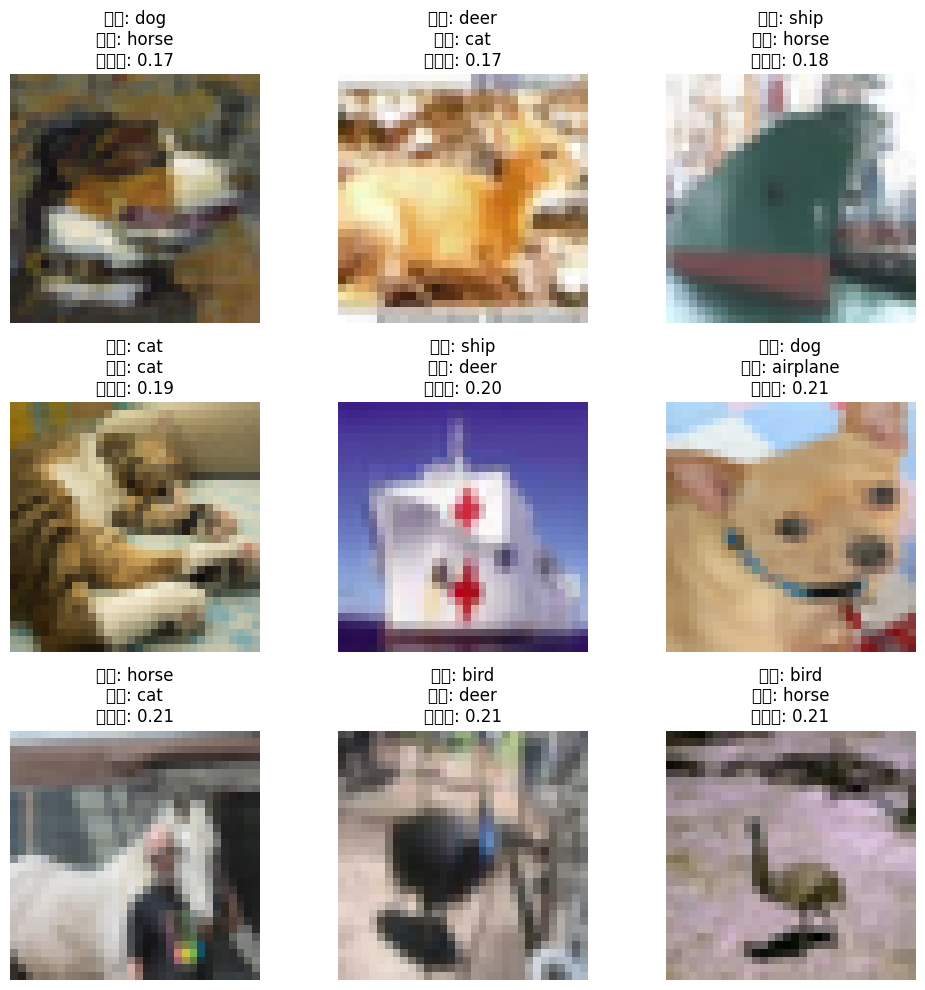

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. 예측 (이미 위에서 했으므로 변수 재사용 가능)
# y_val_pred_proba = model.predict(X_val)
# y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# 2. 혼동행렬 (10×10) 계산
# ✅ 빈칸 채움: confusion_matrix 사용
cm = confusion_matrix(y_val, y_val_pred, labels=range(10))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix (Validation Data)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. 분류 리포트
print("\n분류 리포트:")
# ✅ 빈칸 채움: classification_report 사용
print(classification_report(y_val, y_val_pred, target_names=class_names))

# 4. 클래스별 정확도
print(f"\n클래스별 정확도:")
for i, name in enumerate(class_names):
    class_mask = (y_val == i)
    if class_mask.sum() > 0:
        # ✅ 빈칸 채움: 각 클래스 정확도 계산
        acc = np.mean(y_val_pred[class_mask] == i) 
        print(f"  {name}: {acc:.4f} ({acc*100:.2f}%)")

# 5. 가장 잘못 분류된 샘플 시각화
confidence_scores = np.max(y_val_pred_proba, axis=1)
# 신뢰도가 낮으면서 틀린 것 위주로 정렬
low_confidence_idx = np.argsort(confidence_scores)[:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, idx in enumerate(low_confidence_idx):
    row, col = i // 3, i % 3
    axes[row, col].imshow(X_val[idx])
    actual = class_names[y_val[idx]]
    predicted = class_names[y_val_pred[idx]]
    conf = confidence_scores[idx]
    axes[row, col].set_title(f"실제: {actual}\n예측: {predicted}\n신뢰도: {conf:.2f}")
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

In [7]:
# 파일 생성 전용 셀
import os

# 1. 모델이 있는지 확인
if 'model' in locals():
    print("모델 확인 완료! 예측을 시작합니다.")
    predictions = model.predict(X_test)
    prediction_indices = np.argmax(predictions, axis=1)

    # 2. 데이터프레임 생성
    submission = pd.DataFrame({
        "id": np.arange(1, len(prediction_indices) + 1),
        "label": [class_names[i] for i in prediction_indices]
    })

    # 3. /kaggle/working/ 경로에 확실히 저장
    output_path = "/kaggle/working/submission.csv"
    submission.to_csv(output_path, index=False)

    if os.path.exists(output_path):
        print(f"성공! 파일이 다음 경로에 생성되었습니다: {output_path}")
    else:
        print("파일 생성에 실패했습니다.")
else:
    print("에러: 'model' 변수가 없습니다. 모델 훈련 셀을 먼저 실행하세요!")

모델 확인 완료! 예측을 시작합니다.
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
성공! 파일이 다음 경로에 생성되었습니다: /kaggle/working/submission.csv
